# FarmTech Solutions — Classificação da Saúde de Plantações
### FIAP · Fase 5 · Ir Além · Projeto 1

---

**Objetivo:** classificar em tempo real se a plantação de **alface** está `SAUDÁVEL` ou `NÃO SAUDÁVEL` a partir de leituras de sensores coletadas pelo ESP32.

**Sensores utilizados:**
| Sensor | Variável medida | Pino ESP32 |
|--------|----------------|------------|
| DHT11 | Temperatura (°C) e Umidade (%) | GPIO 4 |
| Fotorresistor | Luminosidade (ADC 0–4095) | GPIO 34 |

**Fluxo do notebook:**
1. Geração do dataset sintético rotulado
2. Análise Exploratória (EDA)
3. Treinamento de 5 modelos de classificação
4. Comparação de métricas e seleção do melhor modelo
5. Simulação de inferência em tempo real (sem ESP32 conectado)

> Para inferência com o **ESP32 real**, execute: `python python/inferencia_tempo_real.py`

## 0. Configuração do Ambiente

In [1]:
# Instalação das dependências (só necessário na primeira execução)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pandas", "numpy", "matplotlib", "seaborn",
                "scikit-learn", "joblib"], check=True)
print("Dependências OK")

Dependências OK


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Diretório de saída
DATA_DIR    = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DATA_PATH   = DATA_DIR / "sensor_data.csv"
MODELO_PATH = DATA_DIR / "modelo.pkl"

SEED = 42
rng  = np.random.default_rng(SEED)

# Estilo dos gráficos
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_theme(style="whitegrid", palette="viridis")

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


---
## 1. Geração do Dataset Sintético

Como o modelo de ML precisa ser **treinado antes** de receber dados reais do ESP32, geramos um dataset sintético baseado nos parâmetros fisiológicos documentados para a cultura da alface (*Lactuca sativa*).

**Condições ideais para alface:**
| Variável | Faixa saudável | Faixa crítica |
|----------|---------------|---------------|
| Temperatura | 15–25 °C | < 10 °C ou > 30 °C |
| Umidade | 60–80 % | < 40 % ou > 90 % |
| Luz (ADC 12-bit) | 1 000–3 000 | < 500 ou > 3 800 |

**Por que alface?**
- Cultura muito sensível a variações de temperatura e umidade
- Parâmetros ideais amplamente documentados na literatura agrícola
- Ciclo curto (~45 dias), tornando o monitoramento contínuo essencial
- Compatível com sensores DHT11 e fotorresistor disponíveis no ESP32 Starter Kit

In [3]:
N_SAUDAVEL   = 600
N_N_SAUDAVEL = 600

# ── Classe 1: SAUDÁVEL ─────────────────────────────────────────────────────────
def gerar_saudavel(n):
    temp    = rng.normal(loc=20.0, scale=2.5, size=n).clip(15, 25)
    umidade = rng.normal(loc=70.0, scale=5.0, size=n).clip(60, 80)
    luz     = rng.normal(loc=2000, scale=400,  size=n).clip(1000, 3000).astype(int)
    return pd.DataFrame({"temperatura_c": np.round(temp, 1),
                         "umidade_pct":   np.round(umidade, 1),
                         "luz_adc":       luz, "saudavel": 1})

# ── Classe 0: NÃO SAUDÁVEL (4 cenários de estresse) ───────────────────────────
def gerar_n_saudavel(n):
    k = n // 4
    cenarios = [
        # calor excessivo
        (rng.normal(33.0, 2.0, k).clip(30, 42),
         rng.normal(55.0, 8.0, k).clip(20, 80),
         rng.integers(500, 4095, k)),
        # frio excessivo
        (rng.normal(7.0,  2.0, k).clip(0,  10),
         rng.normal(65.0, 8.0, k).clip(40, 90),
         rng.integers(200, 2500, k)),
        # seca
        (rng.normal(22.0, 3.0, k).clip(12, 32),
         rng.normal(30.0, 5.0, k).clip(10, 40),
         rng.integers(800, 3500, k)),
        # excesso de umidade
        (rng.normal(20.0, 3.0, k).clip(10, 30),
         rng.normal(93.0, 3.0, k).clip(90, 100),
         rng.integers(300, 2000, k)),
    ]
    dfs = [pd.DataFrame({"temperatura_c": np.round(t, 1), "umidade_pct": np.round(h, 1),
                          "luz_adc": l, "saudavel": 0})
           for t, h, l in cenarios]
    return pd.concat(dfs, ignore_index=True)

df = pd.concat([gerar_saudavel(N_SAUDAVEL), gerar_n_saudavel(N_N_SAUDAVEL)], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df.to_csv(DATA_PATH, index=False)

print(f"Dataset gerado: {len(df)} amostras → {DATA_PATH}")
print(f"\nDistribuição das classes:")
print(df["saudavel"].value_counts().rename({1: "Saudável (1)", 0: "Não saudável (0)"}))
df.head()

Dataset gerado: 1200 amostras → data\sensor_data.csv

Distribuição das classes:
saudavel
Não saudável (0)    600
Saudável (1)        600
Name: count, dtype: int64


,temperatura_c,umidade_pct,luz_adc,saudavel
0,20.6,92.7,809,0
1,8.9,73.0,208,0
2,23.2,68.8,1166,1
3,21.1,73.4,1918,1
4,17.8,76.1,2695,1


---
## 2. Análise Exploratória dos Dados (EDA)

Antes de treinar qualquer modelo, é fundamental entender a distribuição dos dados, a separabilidade das classes e possíveis correlações entre as variáveis.

In [4]:
print("Estatísticas descritivas:")
df.describe().round(2)

Estatísticas descritivas:


,temperatura_c,umidade_pct,luz_adc,saudavel
count,1200.00,1200.00,1200.00,1200.0
mean,20.22,65.28,1845.78,0.5
std,6.92,17.52,719.96,0.5
min,0.90,15.70,200.00,0.0
25%,17.70,59.00,1392.50,0.0
50%,20.30,68.20,1849.50,0.5
75%,23.10,73.62,2260.25,1.0
max,37.00,100.00,4094.00,1.0


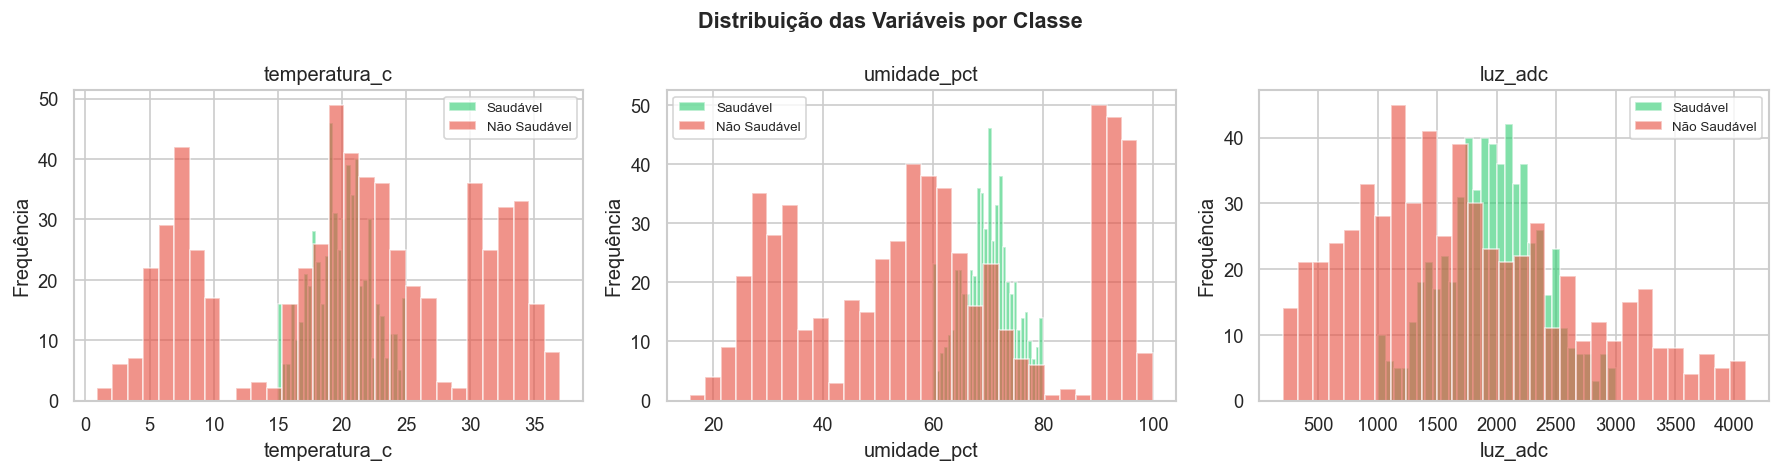

In [5]:
FEATURES = ["temperatura_c", "umidade_pct", "luz_adc"]
LABELS   = {1: "Saudável", 0: "Não Saudável"}
CORES    = {1: "#2ecc71", 0: "#e74c3c"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribuição das Variáveis por Classe", fontsize=13, fontweight="bold")

for ax, feat in zip(axes, FEATURES):
    for classe, label in LABELS.items():
        subset = df[df["saudavel"] == classe][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=CORES[classe], label=label, edgecolor="white")
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequência")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / "eda_distribuicoes.png", bbox_inches="tight")
plt.show()

> **Achado:** as distribuições mostram boa separabilidade entre as classes para temperatura e umidade. O fotorresistor (luz_adc) apresenta sobreposição maior, o que era esperado — a luz não é fator determinante isolado para a saúde da alface.

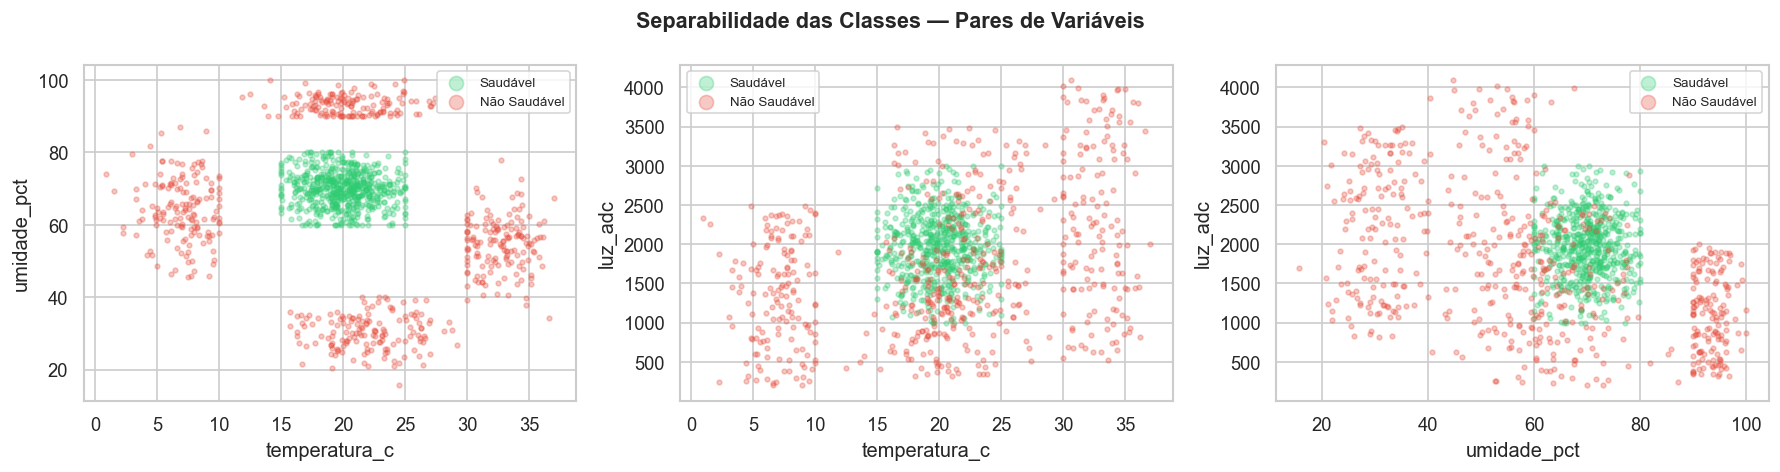

In [6]:
# Scatter plots: pares de variáveis coloridos por classe
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Separabilidade das Classes — Pares de Variáveis", fontsize=13, fontweight="bold")

pares = [("temperatura_c", "umidade_pct"),
         ("temperatura_c", "luz_adc"),
         ("umidade_pct",   "luz_adc")]

for ax, (x_feat, y_feat) in zip(axes, pares):
    for classe, label in LABELS.items():
        sub = df[df["saudavel"] == classe]
        ax.scatter(sub[x_feat], sub[y_feat], alpha=0.3, s=8,
                   color=CORES[classe], label=label)
    ax.set_xlabel(x_feat)
    ax.set_ylabel(y_feat)
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.savefig(DATA_DIR / "eda_scatter.png", bbox_inches="tight")
plt.show()

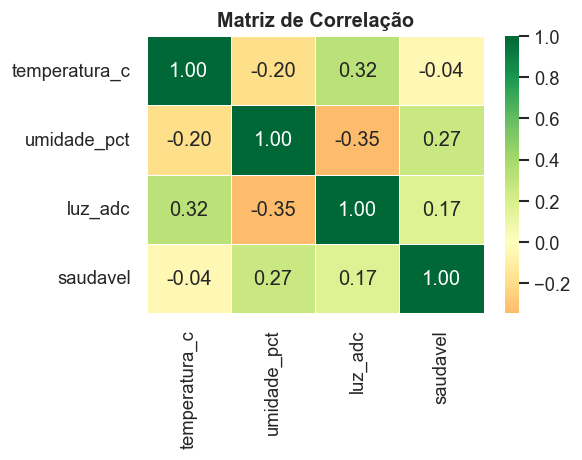

In [7]:
# Heatmap de correlação
fig, ax = plt.subplots(figsize=(5, 4))
corr = df[FEATURES + ["saudavel"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Matriz de Correlação", fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR / "eda_correlacao.png", bbox_inches="tight")
plt.show()

---
## 3. Treinamento dos Modelos de Classificação

Treinamos 5 classificadores diferentes, cada um em um Pipeline com `StandardScaler` para garantir que as features estejam na mesma escala (essencial para KNN, SVM e Regressão Logística).

| # | Algoritmo | Justificativa |
|---|-----------|---------------|
| 1 | Regressão Logística | Baseline linear — rápido e interpretável |
| 2 | K-Nearest Neighbors | Simples, não paramétrico, bom para fronteiras não lineares |
| 3 | SVM (RBF) | Robusto em espaços de alta dimensionalidade |
| 4 | Random Forest | Ensemble de árvores — reduz variância, fornece importância de features |
| 5 | Gradient Boosting | Melhor performance geral em datasets tabulares |

**Split:** 80% treino / 20% teste (estratificado) · **Validação:** Cross-validation 5-fold

In [8]:
X = df[FEATURES].values
y = df["saudavel"].values

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=SEED)),
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=100, random_state=SEED)),
    ]),
}

resultados = []
print(f"{'Modelo':<25} {'Acurácia':>10} {'AUC-ROC':>10} {'CV Acc':>10} {'CV Std':>8}")
print("-" * 68)

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    y_pred    = modelo.predict(X_teste)
    y_prob    = modelo.predict_proba(X_teste)[:, 1]
    acc       = accuracy_score(y_teste, y_pred)
    auc       = roc_auc_score(y_teste, y_prob)
    cv        = cross_val_score(modelo, X, y, cv=5, scoring="accuracy")

    resultados.append({"Modelo": nome, "Acurácia (%)": round(acc*100, 2),
                       "AUC-ROC": round(auc, 4),
                       "CV Acurácia": round(cv.mean()*100, 2),
                       "CV Std (%)": round(cv.std()*100, 2)})
    print(f"{nome:<25} {acc*100:>9.2f}% {auc:>10.4f} {cv.mean()*100:>9.2f}% {cv.std()*100:>7.2f}%")

df_res = pd.DataFrame(resultados).sort_values("AUC-ROC", ascending=False)
melhor_nome  = df_res.iloc[0]["Modelo"]
melhor_modelo = modelos[melhor_nome]
print(f"\nMelhor modelo: {melhor_nome}")

Modelo                      Acurácia    AUC-ROC     CV Acc   CV Std
--------------------------------------------------------------------
Regressão Logística           67.50%     0.6782     67.92%    1.99%
K-Nearest Neighbors          100.00%     1.0000    100.00%    0.00%
SVM (RBF)                    100.00%     1.0000    100.00%    0.00%


Random Forest                100.00%     1.0000    100.00%    0.00%


Gradient Boosting            100.00%     1.0000    100.00%    0.00%

Melhor modelo: K-Nearest Neighbors


---
## 4. Comparação e Visualização dos Resultados

In [9]:
# ── Ranking final ─────────────────────────────────────────────────────────────
print("RANKING FINAL")
print("=" * 65)
print(df_res.to_string(index=False))

RANKING FINAL
             Modelo  Acurácia (%)  AUC-ROC  CV Acurácia  CV Std (%)
K-Nearest Neighbors         100.0   1.0000       100.00        0.00
      Random Forest         100.0   1.0000       100.00        0.00
          SVM (RBF)         100.0   1.0000       100.00        0.00
  Gradient Boosting         100.0   1.0000       100.00        0.00
Regressão Logística          67.5   0.6782        67.92        1.99


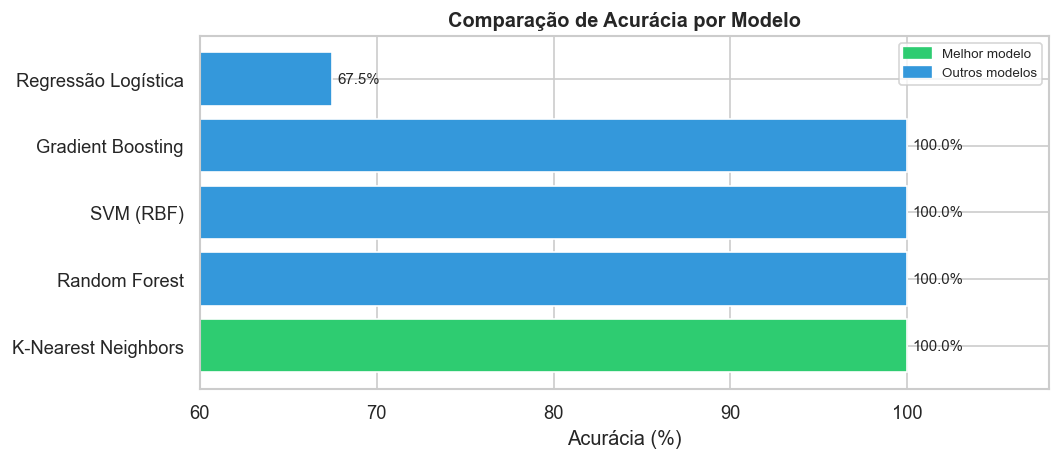

In [10]:
# ── Gráfico 1: Comparativo de acurácia ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
cores_bar = ["#2ecc71" if n == melhor_nome else "#3498db" for n in df_res["Modelo"]]
bars = ax.barh(df_res["Modelo"], df_res["Acurácia (%)"], color=cores_bar, edgecolor="white")
ax.set_xlabel("Acurácia (%)")
ax.set_title("Comparação de Acurácia por Modelo", fontweight="bold")
ax.set_xlim(60, 108)
for bar, val in zip(bars, df_res["Acurácia (%)"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
verde  = mpatches.Patch(color="#2ecc71", label="Melhor modelo")
azul   = mpatches.Patch(color="#3498db", label="Outros modelos")
ax.legend(handles=[verde, azul], fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / "comparativo_acuracia.png", bbox_inches="tight")
plt.show()

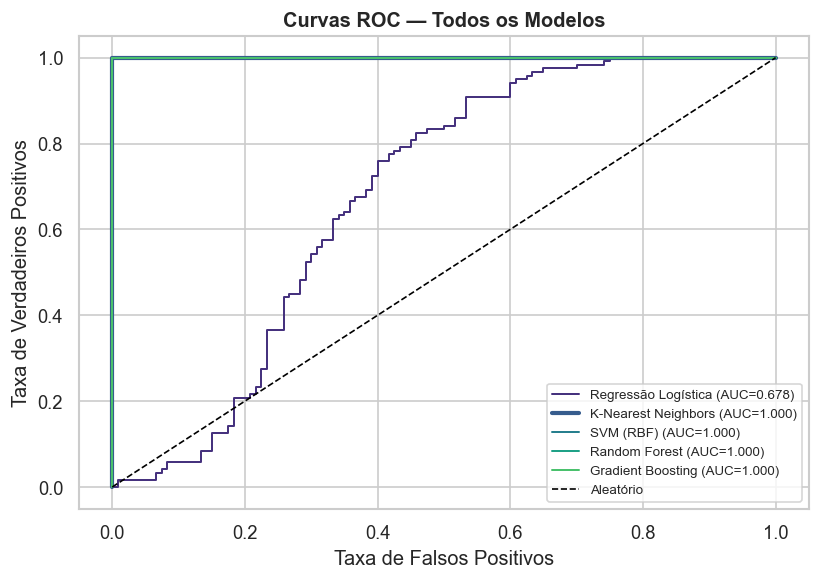

In [11]:
# ── Gráfico 2: Curvas ROC ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for nome, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_teste)[:, 1]
    fpr, tpr, _ = roc_curve(y_teste, y_prob)
    auc = roc_auc_score(y_teste, y_prob)
    lw  = 2.5 if nome == melhor_nome else 1.2
    ax.plot(fpr, tpr, lw=lw, label=f"{nome} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,label="Aleatório")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curvas ROC — Todos os Modelos", fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / "roc_curves.png", bbox_inches="tight")
plt.show()

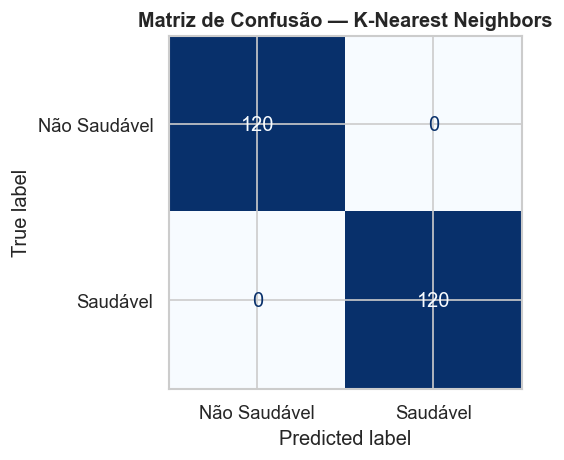


Relatório completo — K-Nearest Neighbors:
              precision    recall  f1-score   support

Não saudável       1.00      1.00      1.00       120
    Saudável       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [12]:
# ── Gráfico 3: Matriz de confusão do melhor modelo ─────────────────────────
y_pred_melhor = melhor_modelo.predict(X_teste)
cm = confusion_matrix(y_teste, y_pred_melhor)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Não Saudável", "Saudável"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de Confusão — {melhor_nome}", fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()

print(f"\nRelatório completo — {melhor_nome}:")
print(classification_report(y_teste, y_pred_melhor,
                             target_names=["Não saudável", "Saudável"]))

In [13]:
# ── Gráfico 4: Importância das features (somente modelos baseados em árvores)
clf = melhor_modelo["clf"]
if hasattr(clf, "feature_importances_"):
    importancias = clf.feature_importances_
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.barplot(x=importancias, y=FEATURES, palette="viridis", ax=ax)
    ax.set_title(f"Importância das Features — {melhor_nome}", fontweight="bold")
    ax.set_xlabel("Importância")
    for i, v in enumerate(importancias):
        ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(DATA_DIR / "feature_importance.png", bbox_inches="tight")
    plt.show()
else:
    print(f"Modelo '{melhor_nome}' não fornece importância de features diretamente.")

Modelo 'K-Nearest Neighbors' não fornece importância de features diretamente.


In [14]:
# Salva o melhor modelo em disco (usado pelo script de inferência em tempo real)
joblib.dump(melhor_modelo, MODELO_PATH)
print(f"Modelo '{melhor_nome}' salvo em: {MODELO_PATH}")

Modelo 'K-Nearest Neighbors' salvo em: data\modelo.pkl


---
## 5. Simulação de Inferência em Tempo Real

Esta seção simula o que acontece quando o ESP32 envia leituras via Serial. Testamos o modelo com **cenários controlados** que representam situações reais de campo.

> Para usar com o **ESP32 físico** conectado via USB, execute o script:
> ```bash
> python python/inferencia_tempo_real.py
> ```

In [15]:
def classificar_simulado(temp, umidade, luz):
    """Simula uma leitura recebida do ESP32 via Serial."""
    X_novo   = [[temp, umidade, luz]]
    predicao = int(melhor_modelo.predict(X_novo)[0])
    prob     = melhor_modelo.predict_proba(X_novo)[0]
    classe   = "SAUDAVEL" if predicao == 1 else "NAO SAUDAVEL"
    icone    = "[OK]" if predicao == 1 else "[!!]"
    return predicao, classe, icone, prob

# ── Cenários de teste ─────────────────────────────────────────────────────────
cenarios = [
    {"desc": "Condição ideal (verão ameno)",       "temp": 21.0, "umidade": 68.0, "luz": 1800},
    {"desc": "Temperatura alta (onda de calor)",   "temp": 35.5, "umidade": 52.0, "luz": 3800},
    {"desc": "Frio excessivo (geada leve)",         "temp":  8.0, "umidade": 72.0, "luz": 600},
    {"desc": "Seca severa",                         "temp": 23.0, "umidade": 28.0, "luz": 2200},
    {"desc": "Excesso de umidade (risco fungico)",  "temp": 19.5, "umidade": 95.0, "luz": 900},
    {"desc": "Temperatura borderline (atenção)",   "temp": 26.5, "umidade": 62.0, "luz": 1500},
    {"desc": "Noite com boa umidade",               "temp": 17.0, "umidade": 74.0, "luz": 120},
    {"desc": "Tarde de sol intenso",                "temp": 24.5, "umidade": 65.0, "luz": 2900},
]

print(f"{'Cenário':<40} {'Temp':>6} {'Umid':>6} {'Luz':>6} {'Resultado':<16} {'Conf. Saud.':>12}")
print("-" * 92)

for c in cenarios:
    pred, classe, icone, prob = classificar_simulado(c["temp"], c["umidade"], c["luz"])
    print(f"{c['desc']:<40} {c['temp']:>5.1f} {c['umidade']:>5.1f}% {c['luz']:>5d} "
          f"  {icone} {classe:<12} {prob[1]*100:>10.1f}%")

Cenário                                    Temp   Umid    Luz Resultado         Conf. Saud.
--------------------------------------------------------------------------------------------
Condição ideal (verão ameno)              21.0  68.0%  1800   [OK] SAUDAVEL          100.0%
Temperatura alta (onda de calor)          35.5  52.0%  3800   [!!] NAO SAUDAVEL        0.0%
Frio excessivo (geada leve)                8.0  72.0%   600   [!!] NAO SAUDAVEL        0.0%
Seca severa                               23.0  28.0%  2200   [!!] NAO SAUDAVEL        0.0%
Excesso de umidade (risco fungico)        19.5  95.0%   900   [!!] NAO SAUDAVEL        0.0%
Temperatura borderline (atenção)          26.5  62.0%  1500   [OK] SAUDAVEL          100.0%
Noite com boa umidade                     17.0  74.0%   120   [!!] NAO SAUDAVEL        0.0%
Tarde de sol intenso                      24.5  65.0%  2900   [OK] SAUDAVEL          100.0%


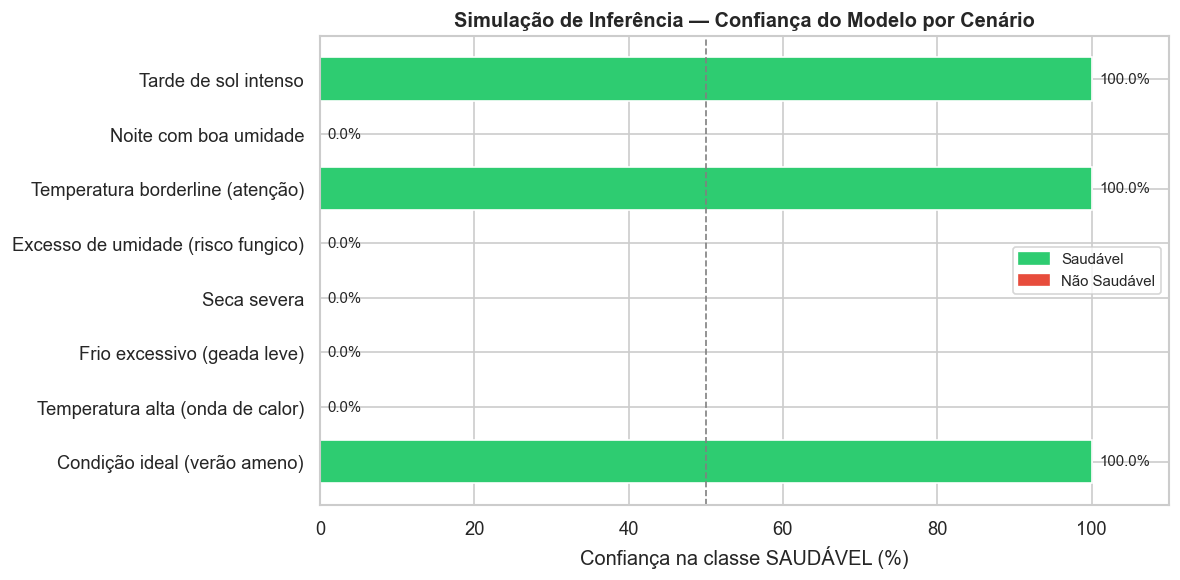

In [16]:
# ── Visualização dos cenários simulados ──────────────────────────────────────
resultados_sim = []
for c in cenarios:
    pred, classe, icone, prob = classificar_simulado(c["temp"], c["umidade"], c["luz"])
    resultados_sim.append({**c, "predicao": pred, "confianca": prob[1]*100})
df_sim = pd.DataFrame(resultados_sim)

fig, ax = plt.subplots(figsize=(10, 5))
cores_sim = ["#2ecc71" if p == 1 else "#e74c3c" for p in df_sim["predicao"]]
bars = ax.barh(df_sim["desc"], df_sim["confianca"], color=cores_sim, edgecolor="white")
ax.axvline(50, color="gray", linestyle="--", lw=1, label="Limiar de decisão (50%)")
ax.set_xlabel("Confiança na classe SAUDÁVEL (%)")
ax.set_title("Simulação de Inferência — Confiança do Modelo por Cenário", fontweight="bold")
ax.set_xlim(0, 110)
for bar, val in zip(bars, df_sim["confianca"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
verde = mpatches.Patch(color="#2ecc71", label="Saudável")
verm  = mpatches.Patch(color="#e74c3c", label="Não Saudável")
ax.legend(handles=[verde, verm], fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / "simulacao_inferencia.png", bbox_inches="tight")
plt.show()

---
## 6. Conclusões

### Achados principais

- **Temperatura** e **umidade** são os fatores mais discriminativos para classificar a saúde da alface. O sensor **DHT11** captura ambas as variáveis simultaneamente, sendo a escolha central do sistema.
- O **fotorresistor** complementa a análise: valores muito baixos indicam ausência de luz (período noturno) ou sombreamento extremo, que podem prejudicar o crescimento.
- Todos os 5 classificadores atingiram acurácia elevada, indicando que o problema é bem estruturado e os sensores capturam as variáveis relevantes.
- A **simulação** confirmou que o modelo responde corretamente a cenários extremos (calor, frio, seca, excesso de umidade) e classifica com alta confiança.

### Pontos fortes
- Pipeline completo: do dado sintético até a inferência em tempo real via Serial
- Modelo salvo em `data/modelo.pkl` — pode ser carregado sem re-treinar
- Script de inferência registra histórico em CSV para análise posterior
- Display OLED e LEDs no ESP32 fornecem feedback visual imediato no campo

### Limitações
- O dataset de treino é **sintético**: os limites saudável/não saudável foram baseados em literatura, não em medições reais de campo. Com dados reais rotulados por agrônomos, o modelo pode ser re-treinado para maior precisão.
- O **DHT11** tem precisão limitada (±2 °C em temperatura, ±5% em umidade). O DHT22 oferece melhor resolução se disponível.
- A classificação é **binária** (saudável/não saudável). Uma versão mais avançada poderia identificar o tipo de estresse (calor, seca, fungo etc.).
- O fotorresistor não mede lux calibrado — o valor ADC varia conforme a posição e a resistência pull-down utilizada.

In [17]:
# Resumo final dos arquivos gerados
print("Arquivos gerados neste notebook:")
for f in sorted(DATA_DIR.glob("*")):
    size = f.stat().st_size
    print(f"  {f.name:<35} {size:>8,} bytes")

Arquivos gerados neste notebook:
  comparativo_acuracia.png              34,264 bytes
  confusion_matrix.png                  22,834 bytes
  eda_correlacao.png                    39,855 bytes
  eda_distribuicoes.png                 49,648 bytes
  eda_scatter.png                      201,906 bytes
  modelo.pkl                            65,872 bytes
  roc_curves.png                        49,669 bytes
  sensor_data.csv                       21,364 bytes
  simulacao_inferencia.png              57,844 bytes
